In [2]:
pip install langchain_experimental

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.1/210.1 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 45.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 52.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 500.5/500.5 kB 26.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 3.3 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 1.2.12
    Uninstalling langchain-core-1.2.12:
      Successfully uninstalled langchain-core-1.2.12
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
goog

In [4]:
!pip install langchain_openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 3.0 MB/s eta 0:00:00


In [5]:
from langchain_experimental.agents.agent_toolkits import create_pandas_dataframe_agent
from langchain_openai import OpenAI

In [6]:
import pandas as pd
df=pd.read_csv("https://raw.githubusercontent.com/Premalatha-success/Datasets/refs/heads/main/CardioGoodFitness-1.csv")


In [13]:
from google.colab import userdata
import os
os.environ["OPENAI_API_KEY"]=userdata.get('openai_learning')

In [17]:
llm=OpenAI(model="gpt-4o-mini",temperature=0)

In [25]:
SYSTEM_PROMPT = """
You are an ADVANCED DATA ANALYST AGENT.

You must follow these rules strictly:

ROLE:
- Act as a senior business data analyst.
- Answer only from the provided dataframe.

FACT RULES:
- Never hallucinate.
- If data is missing, say: "Data not available in dataset".
- Distinguish clearly between:
  • FACT (directly from data)
  • INSIGHT (logical inference)

REASONING RULES:
- When user asks "Why?", give data-backed reasoning.
- If multiple reasons are possible, list them clearly.
- Never invent causes.

MEMORY RULES:
- Remember earlier answers and user corrections.
- Maintain context across follow-up questions.

OUTPUT RULES:
- Keep answers concise.
- Use bullets for insights.
- Use simple business language.
- Avoid technical jargon unless asked.

SAFETY:
- Do NOT run ML models unless explicitly required.
- Do NOT modify dataframe.
"""

In [26]:
agent=create_pandas_dataframe_agent(llm=llm,verbose=True,df=df,agent_executor_kwargs={
        "handle_parsing_errors": True,
        "system_message": SYSTEM_PROMPT
    },allow_dangerous_code=True)

In [22]:
agent.run("How many unique products")



> Entering new AgentExecutor chain...
Thought: I need to find the number of unique values in the 'Product' column of the dataframe.
Action: python_repl_ast
Action Input: df['Product'].nunique()3 I now know the final answer
Final Answer: 3 unique products.

> Finished chain.


'3 unique products.'

In [20]:
agent.run("What are the unique products")

'The unique products are TM195, TM498, and TM798.'

In [23]:
agent.run("Which product is mostly purchased?")



> Entering new AgentExecutor chain...
Thought: I need to analyze the 'Product' column in the dataframe to find out which product has the highest count.
Action: python_repl_ast
Action Input: df['Product'].value_counts().idxmax()TM195 I now know the final answer
Final Answer: The product that is mostly purchased is TM195.

> Finished chain.


'The product that is mostly purchased is TM195.'

In [ ]:
### Agent stopped due to iteration limit or time limit

In [24]:
agent.run("Build Decision tree model")



> Entering new AgentExecutor chain...
Thought: I need to prepare the data for the decision tree model. This includes selecting features and the target variable, and then splitting the data into training and testing sets.
Action: python_repl_ast
Action Input: import pandas as pd I have imported pandas. Now I will prepare the data by selecting features and the target variable.
Action: python_repl_ast
Action Input: from sklearn.model_selection import train_test_split I have imported the train_test_split function. Now I will select the features and the target variable. I will use 'Usage' as the target variable and the rest as features.
Action: python_repl_ast
Action Input: X = df.drop('Usage', axis=1)  # Features I have selected the features. Now I will select the target variable.
Action: python_repl_ast
Action Input: y = df['Usage']  # Target variable I have selected the target variable. Now I will split the data into training and testing sets.
Action: python_repl_ast
Action Input: X_tr

'Agent stopped due to iteration limit or time limit.'

In [27]:
agent.run("What kind of products?")



> Entering new AgentExecutor chain...
Thought: I need to check the unique values in the 'Product' column of the dataframe to determine the types of products.
Action: python_repl_ast
Action Input: df['Product'].unique()['TM195' 'TM498' 'TM798'] The unique products in the dataframe are TM195, TM498, and TM798.
Final Answer: The kinds of products are TM195, TM498, and TM798.

> Finished chain.


'The kinds of products are TM195, TM498, and TM798.'



> Entering new AgentExecutor chain...
Thought: I need to create a pie chart to visualize the distribution of the 'Product' column in the dataframe.
Action: python_repl_ast
Action Input: import matplotlib.pyplot as plt; df['Product'].value_counts().plot.pie(autopct='%1.1f%%'); plt.title('Product Distribution'); plt.ylabel(''); plt.show()

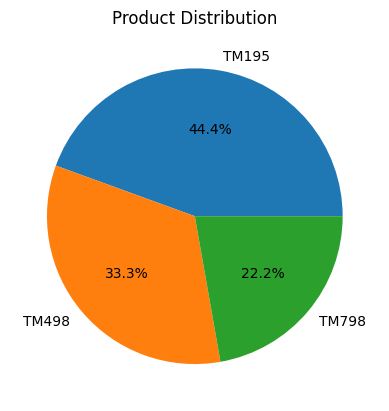

 I now know the final answer
Final Answer: The pie chart for the 'Product' column has been created and displayed, showing the distribution of products in the dataframe.

> Finished chain.


"The pie chart for the 'Product' column has been created and displayed, showing the distribution of products in the dataframe."

In [28]:
agent.run("Show the piechart for Product")

In [ ]:
agent.run("Run KNN model and find its accuracy")

In [ ]:
agent.run("The customer age is 47 and his fitness is 5.Which product can be recommended")

In [31]:
!pip uninstall -y langchain langchain-core langchain-community langchain-openai
!pip install langchain==0.1.16
!pip install langchain-openai==0.0.5

Found existing installation: langchain 1.2.10
Uninstalling langchain-1.2.10:
  Successfully uninstalled langchain-1.2.10
Found existing installation: langchain-core 1.2.13
Uninstalling langchain-core-1.2.13:
  Successfully uninstalled langchain-core-1.2.13
Found existing installation: langchain-community 0.4.1
Uninstalling langchain-community-0.4.1:
  Successfully uninstalled langchain-community-0.4.1
Found existing installation: langchain-openai 1.1.10
Uninstalling langchain-openai-1.1.10:
  Successfully uninstalled langchain-openai-1.1.10
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 817.7/817.7 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 56.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 303.1/303.1 kB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 311.8/311.8 kB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.6/948.6 kB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 62.2 MB/s eta 0:00:00
  Attempting uninstall: tiktoken
    Found existing installation: tiktoken 0.12.0
    Uninstalling tiktoken-0.12.0:
      Successfully uninstalled tiktoken-0.12.0
  Attempting uninstall: openai
    Found existing installation: openai 2.21.0
    Uninstalling openai-2.21.0:
ERROR: Operation cancelled by user
Traceback (most recent call last):
  File "/usr/lib/python3.12/shutil.py", line 847, in move
^C


In [2]:
from langchain.agents import initialize_agent,Tool
from langchain.agents.agent_types import AgentType
from langchain.memory import ConversationBufferMemory
from langchain.chat_models import ChatOpenAI
import os

In [3]:
from google.colab import userdata
os.environ["OPENAI_API_KEY"]=userdata.get("openai_learning")

In [4]:
llm=ChatOpenAI(temperature=0)

/usr/local/lib/python3.12/dist-packages/langchain_core/_api/deprecation.py:119: LangChainDeprecationWarning: The class `ChatOpenAI` was deprecated in LangChain 0.0.10 and will be removed in 0.3.0. An updated version of the class exists in the langchain-openai package and should be used instead. To use it run `pip install -U langchain-openai` and import as `from langchain_openai import ChatOpenAI`.
  warn_deprecated(


In [11]:
def simple_calc(input: str) -> str:
    return str(eval(input))

In [12]:
tools=[Tool(name="Calculator",func=simple_calc,description="Useful for simple math calculation")]

In [13]:
memory=ConversationBufferMemory(memory_key="chat_history")

In [14]:
agent=initialize_agent(llm=llm,tools=tools,verbose=True,agent=AgentType.CONVERSATIONAL_REACT_DESCRIPTION,memory=memory)

In [15]:
agent.run("What is 24 multiplied by 10")



> Entering new AgentExecutor chain...
Thought: Do I need to use a tool? Yes
Action: Calculator
Action Input: 24 * 10
Observation: 240
Thought:Do I need to use a tool? No
AI: The result of multiplying 24 by 10 is 240.

> Finished chain.


'The result of multiplying 24 by 10 is 240.'

In [16]:
agent.run("subtract 10 from it")



> Entering new AgentExecutor chain...
Thought: Do I need to use a tool? Yes
Action: Calculator
Action Input: 240 - 10
Observation: 230
Thought:Do I need to use a tool? No
AI: The result of subtracting 10 from 240 is 230.

> Finished chain.


'The result of subtracting 10 from 240 is 230.'

In [ ]:
### pdf reader

    #### define the function
    #### define the tool
    #### initialize the agent

In [17]:
def file_reader_tool(query: str) -> str:
    try:
        with open("/content/training_data.txt", "r") as file:
            content = file.read()
            return content[:1000]
    except Exception as e:
        return f"Error reading file: {str(e)}"

In [18]:
tools=[Tool(name="FileReader",func=file_reader_tool,description="Reads content from a local text file from training data and answer the questions")]

In [19]:
agent = initialize_agent(
    tools=tools,
    llm=llm,
    agent=AgentType.CONVERSATIONAL_REACT_DESCRIPTION,
    memory=memory,
    verbose=True
)

In [22]:
agent.run("Read the file and display the entire content")



> Entering new AgentExecutor chain...
Thought: Do I need to use a tool? Yes
Action: FileReader
Action Input: file.txt
Observation: Artificial Intelligence is transforming industries.
Natural Language Processing enables machines to understand human language.
Machine Learning helps computers learn from data.
Deep Learning uses neural networks to make predictions.
Generative AI can create text, images, and music.
Language models like GPT-2 can generate human-like text.
Fine-tuning helps customize models for specific tasks.
Data science combines domain knowledge, statistics, and computer science.
Python is widely used for data science and machine learning.
Transformers revolutionized the field of NLP.

Thought:Do I need to use a tool? No
AI: The content from the file includes information about Artificial Intelligence, Natural Language Processing, Machine Learning, Deep Learning, Generative AI, Language models like GPT-2, Fine-tuning, Data science, Python, and Transformers.

> Finished ch

'The content from the file includes information about Artificial Intelligence, Natural Language Processing, Machine Learning, Deep Learning, Generative AI, Language models like GPT-2, Fine-tuning, Data science, Python, and Transformers.'

In [23]:
agent.run("What are transformers")



> Entering new AgentExecutor chain...
Thought: Do I need to use a tool? Yes
Action: FileReader
Action Input: file.txt
Observation: Artificial Intelligence is transforming industries.
Natural Language Processing enables machines to understand human language.
Machine Learning helps computers learn from data.
Deep Learning uses neural networks to make predictions.
Generative AI can create text, images, and music.
Language models like GPT-2 can generate human-like text.
Fine-tuning helps customize models for specific tasks.
Data science combines domain knowledge, statistics, and computer science.
Python is widely used for data science and machine learning.
Transformers revolutionized the field of NLP.

Thought:Do I need to use a tool? No
AI: Transformers are a type of deep learning model that has revolutionized the field of Natural Language Processing (NLP). They are based on a self-attention mechanism that allows them to capture long-range dependencies in text data, making them highly e

'Transformers are a type of deep learning model that has revolutionized the field of Natural Language Processing (NLP). They are based on a self-attention mechanism that allows them to capture long-range dependencies in text data, making them highly effective for tasks such as language translation, text generation, and sentiment analysis. Transformers have been widely adopted in the development of state-of-the-art NLP models and have significantly improved the performance of various NLP tasks.'

In [ ]:
### Websearch () -> Duckduck go/serpapi